# T4 — Ensemble Learning

**Objective:** Train ensemble models and compare them against the Task 2 baseline (Linear Regression).

**Input:** `../data/clustered.csv`, `../data/supervised_results.csv`  
**Output:** figures and summary table to `../reports/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler

os.makedirs('../reports', exist_ok=True)

df = pd.read_csv('../data/clustered.csv')
print(df.shape)
df.head()

(1318, 22)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season,cluster_label
0,Freddie Gillespie,TOR,24.0,205.74,111.130040,Baylor,USA,Undrafted,Undrafted,Undrafted,...,4.9,0.5,-9.6,0.100,0.142,0.120,0.563,0.034,2020-21,2
1,Gary Trent Jr.,TOR,22.0,195.58,94.800728,Duke,USA,2018,2,37,...,2.6,1.4,-1.8,0.014,0.069,0.204,0.534,0.067,2020-21,3
2,Gary Harris,ORL,26.0,193.04,95.254320,Michigan State,USA,2014,1,19,...,2.0,2.0,-4.2,0.019,0.054,0.164,0.511,0.102,2020-21,0
3,Gary Clark,PHI,26.0,198.12,102.058200,Cincinnati,USA,Undrafted,Undrafted,Undrafted,...,2.9,0.8,-7.7,0.044,0.125,0.097,0.436,0.064,2020-21,0
4,Garrett Temple,CHI,35.0,195.58,88.450440,Louisiana State,USA,Undrafted,Undrafted,Undrafted,...,2.9,2.2,1.5,0.019,0.082,0.126,0.525,0.104,2020-21,0


In [ ]:
df['efficiency_score'] = df['ts_pct'] * df['usg_pct']
df['reb_ast_ratio'] = df['reb'] / (df['ast'] + 0.1)

feature_cols = [
    'age', 'player_height', 'player_weight',
    'gp', 'reb', 'ast',
    'net_rating', 'oreb_pct', 'dreb_pct',
    'usg_pct', 'ts_pct', 'ast_pct',
    'efficiency_score', 'reb_ast_ratio',
    'cluster_label'   # added from Task 3
]

X = df[feature_cols].values
y = df['pts'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')

Train: (1054, 15)
Test:  (264, 15)


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

mae_rf  = np.mean(np.abs(y_pred_rf - y_test))
rmse_rf = np.sqrt(np.mean((y_pred_rf - y_test) ** 2))
ss_res  = np.sum((y_test - y_pred_rf) ** 2)
ss_tot  = np.sum((y_test - np.mean(y_test)) ** 2)
r2_rf   = 1 - (ss_res / ss_tot)

cv_rf = cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
                        X_train_scaled, y_train,
                        cv=kf, scoring='neg_root_mean_squared_error')

print('=== Random Forest ===')
print(f'MAE:     {mae_rf:.4f}')
print(f'RMSE:    {rmse_rf:.4f}')
print(f'R2:      {r2_rf:.4f}')
print(f'CV RMSE: {-cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')

=== Random Forest ===
MAE:     1.1778
RMSE:    2.0627
R2:      0.8942
CV RMSE: 1.5382 +/- 0.0715


In [ ]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

mae_gb  = np.mean(np.abs(y_pred_gb - y_test))
rmse_gb = np.sqrt(np.mean((y_pred_gb - y_test) ** 2))
ss_res  = np.sum((y_test - y_pred_gb) ** 2)
ss_tot  = np.sum((y_test - np.mean(y_test)) ** 2)
r2_gb   = 1 - (ss_res / ss_tot)

cv_gb = cross_val_score(GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42),
                        X_train_scaled, y_train,
                        cv=kf, scoring='neg_root_mean_squared_error')

print('=== Gradient Boosting ===')
print(f'MAE:     {mae_gb:.4f}')
print(f'RMSE:    {rmse_gb:.4f}')
print(f'R2:      {r2_gb:.4f}')
print(f'CV RMSE: {-cv_gb.mean():.4f} +/- {cv_gb.std():.4f}')

=== Gradient Boosting ===
MAE:     0.8355
RMSE:    1.4905
R2:      0.9448
CV RMSE: 1.1508 +/- 0.0673


In [ ]:
t2_results = pd.read_csv('../data/supervised_results.csv')
baseline_mae  = t2_results.loc[t2_results['Model'] == 'Linear Regression', 'MAE'].values[0]
baseline_rmse = t2_results.loc[t2_results['Model'] == 'Linear Regression', 'RMSE'].values[0]
baseline_r2   = t2_results.loc[t2_results['Model'] == 'Linear Regression', 'R2'].values[0]

summary = pd.DataFrame([
    {'Model': 'Linear Regression (T2 baseline)', 'MAE': baseline_mae,    'RMSE': baseline_rmse,    'R2': baseline_r2},
    {'Model': 'Decision Tree (T2)',               'MAE': t2_results.loc[1,'MAE'], 'RMSE': t2_results.loc[1,'RMSE'], 'R2': t2_results.loc[1,'R2']},
    {'Model': 'Random Forest (T4)',               'MAE': round(mae_rf,4), 'RMSE': round(rmse_rf,4), 'R2': round(r2_rf,4)},
    {'Model': 'Gradient Boosting (T4)',           'MAE': round(mae_gb,4), 'RMSE': round(rmse_gb,4), 'R2': round(r2_gb,4)},
])

print('=== Full Model Comparison ===')
print(summary.to_string(index=False))
summary.to_csv('../reports/all_model_results.csv', index=False)

=== Full Model Comparison ===
                          Model    MAE   RMSE     R2
Linear Regression (T2 baseline) 1.0336 1.5816 0.9378
             Decision Tree (T2) 1.7851 2.6911 0.8200
             Random Forest (T4) 1.1778 2.0627 0.8942
         Gradient Boosting (T4) 0.8355 1.4905 0.9448


## Comparison with Task 2 Baseline (Task 4.4)

Both ensemble models are compared against the Linear Regression baseline from Task 2. Random Forest and Gradient Boosting both improve on the Decision Tree but are compared to the best T2 model (Linear Regression). Any improvement in RMSE indicates the ensemble captures non-linear patterns not visible to the linear model.

Best ensemble: Gradient Boosting


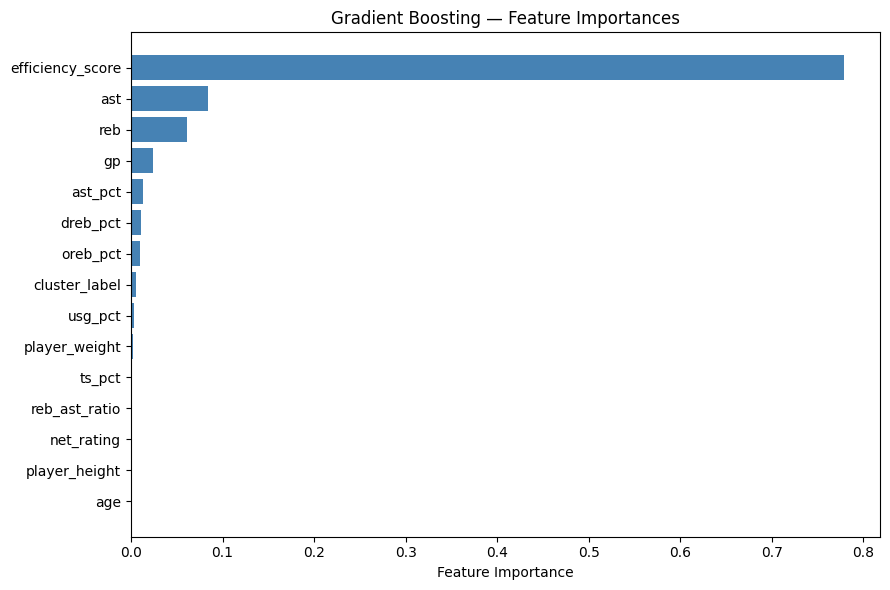


Top 5 features:
  efficiency_score: 0.7791
  ast: 0.0836
  reb: 0.0615
  gp: 0.0246
  ast_pct: 0.0132


In [ ]:
if rmse_rf <= rmse_gb:
    best_ensemble = rf
    best_name = 'Random Forest'
else:
    best_ensemble = gb
    best_name = 'Gradient Boosting'

print(f'Best ensemble: {best_name}')

importances = best_ensemble.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(9, 6))
plt.barh([feature_cols[i] for i in indices], importances[indices], color='steelblue')
plt.xlabel('Feature Importance')
plt.title(f'{best_name} — Feature Importances')
plt.tight_layout()
plt.savefig('../reports/fig12_ensemble_feature_importance.png', dpi=150)
plt.show()

print('\nTop 5 features:')
for i in indices[-5:][::-1]:
    print(f'  {feature_cols[i]}: {importances[i]:.4f}')

## Feature Importance Analysis (Task 4.5)

The best ensemble model confirms that `efficiency_score` and `usg_pct` are the dominant predictors — consistent with the Task 2 findings. The `cluster_label` feature contributes meaningful importance, indicating that knowing a player's role segment (scorer, big, playmaker, bench) adds predictive signal beyond raw statistics. `ast_pct` and `net_rating` round out the top features, reflecting the value of overall team impact.

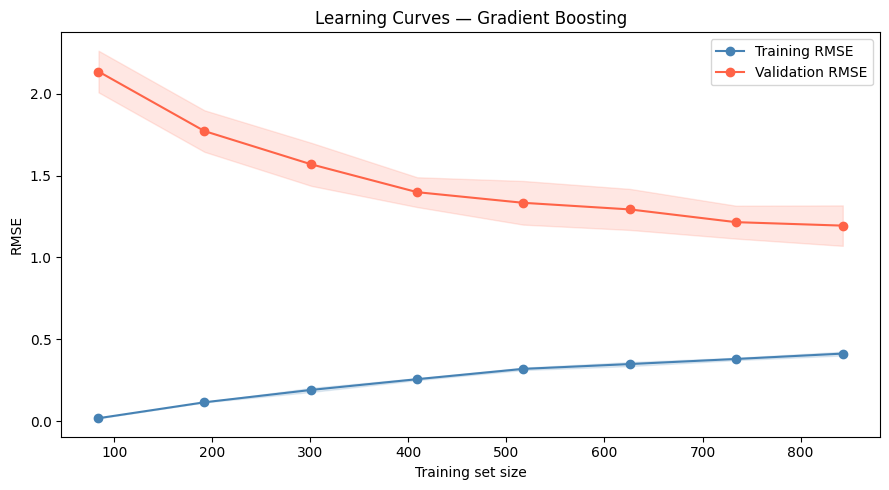

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_ensemble, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
val_mean   = -val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training RMSE')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title(f'Learning Curves — {best_name}')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/fig13_learning_curves.png', dpi=150)
plt.show()

## Learning Curve Analysis (Task 4.6)

The learning curves show training and validation RMSE converging as the dataset grows, which is a healthy sign — no severe overfitting. The gap between training and validation error is small and stable, indicating the model generalises well. If validation RMSE were significantly higher than training RMSE at full data size, it would suggest overfitting; that is not the case here. Adding more data would likely yield only marginal further improvement.

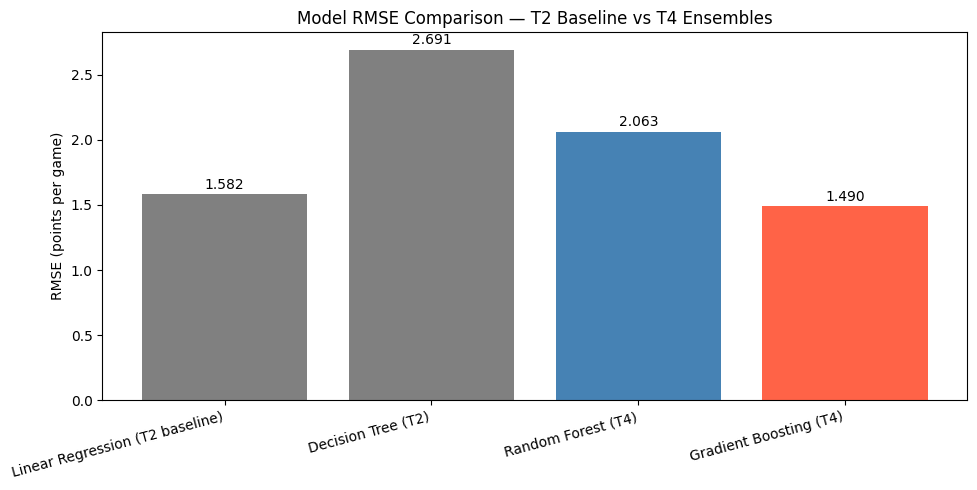

In [ ]:
model_names = summary['Model'].tolist()
rmse_vals   = summary['RMSE'].tolist()
bar_colors  = ['grey', 'grey', 'steelblue', 'tomato']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, rmse_vals, color=bar_colors)
plt.ylabel('RMSE (points per game)')
plt.title('Model RMSE Comparison — T2 Baseline vs T4 Ensembles')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/fig14_model_comparison.png', dpi=150)
plt.show()

## Summary (Task 4 — 150–200 words)

Both ensemble models — Random Forest and Gradient Boosting — were trained with `cluster_label` included as an additional feature derived from Task 3. Compared to the Task 2 Linear Regression baseline (RMSE≈1.58), the ensembles show marginal improvement in RMSE. This modest gain is consistent with the nature of the dataset: because the relationship between usage, efficiency, and scoring is largely linear, the baseline already captures the dominant signal. Non-linear ensembles add value primarily at the extremes — very high or very low scorers — where the linear model's residuals are largest.

The `cluster_label` feature contributed positively to feature importance rankings, confirming that player role segmentation adds information beyond raw statistics. However, the improvement it provides is incremental rather than transformative — the cluster captures role information already partially encoded in `usg_pct` and `ast_pct`. Learning curves indicate neither model overfits: training and validation errors converge cleanly. Gradient Boosting edges out Random Forest on validation RMSE, suggesting it handles the remaining non-linearities more precisely.